Assuming that all the labels are lowercase in HVU dataset

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2, venn3
import re
from difflib import get_close_matches
from fuzzywuzzy import process
from sentence_transformers import SentenceTransformer, util

/home/ahmad/miniconda3/lib/python3.11/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')
/home/ahmad/miniconda3/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
2025-01-22 03:13:56.840185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737512036.891649    9676 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737512036.905134

### HVU dataset

In [2]:
hvu_train_df = pd.read_csv("/home/ahmad/cvr/HVU-Dataset/HVU_Train_V1.0.csv")
hvu_val_df = pd.read_csv("/home/ahmad/cvr/HVU-Dataset/HVU_Val_V1.0.csv")

In [3]:
hvu_train_df.head()

,Tags,youtube_id,time_start,time_end
0,brass_instrument|musical_instrument|trumpet|wo...,OLpWTpTC4P8,57.0,67.0
1,gadget|electronic_musical_instrument|electroni...,pjj6zedpCQY,75.0,85.0
2,photograph|joint|shoulder|nature|human_leg|fun...,_STSOsITd0E,3.0,13.0
3,mouth|child|fun|nose|hair|human_hair_color|hea...,0r_BGL3416g,406.0,416.0
4,photograph|violist|cellist|violin_family|night...,xsPKW4tZZBc,233.0,243.0


In [4]:
hvu_val_df.head()

,Tags,youtube_id,time_start,time_end
0,striking_combat_sports|uniform|competition|jap...,gD_G1b0wV5I,101.5,103.5
1,house|plant|sky|residential_area|land_lot|tree...,eeEC-oWWAM0,90.5,92.5
2,water|swimmer|floating|leisure|playing_water_p...,Np0jqmKPvSQ,170.5,172.5
3,percussion|cymbal|drumhead|metal|skin_head_per...,s2I4-ErSc7E,182.0,184.0
4,fixing_the_roof|wood,TLZXKaS2abQ,31.0,33.0


In [5]:
print(f"Total items in HVU Train file: {hvu_train_df.shape[0]}")
print(f"Total items in HVU Val file: {hvu_val_df.shape[0]}")

Total items in HVU Train file: 481417
Total items in HVU Val file: 31171


In [6]:
#HVU Labels dataset
hvu_labels = pd.read_csv("/home/ahmad/cvr/HVU-Dataset/HVU_Tags_Categories_V1.0.csv")
hvu_labels

,Tag,Category
0,playing_trombone,action
1,playing_controller,action
2,photograph,action
3,recreation,action
4,sitting,action
...,...,...
3137,seaside,scene
3138,riverbed,scene
3139,paddy_field,scene
3140,littoral,scene


#### Combining the dataset with the filenames

In [7]:
hvu_train_files = pd.read_csv("/home/ahmad/cvr/HVU-Dataset/train_file.csv")
hvu_val_files = pd.read_csv("/home/ahmad/cvr/HVU-Dataset/val_file.csv")
hvu_test_files = pd.read_csv("/home/ahmad/cvr/HVU-Dataset/test_file.csv")

In [8]:
print(f"Total items in HVU Train file list: {hvu_train_files.shape[0]}")
print(f"Total items in HVU Val file list: {hvu_val_files.shape[0]}")
print(f"Total items in HVU Test file list: {hvu_test_files.shape[0]}")

Total items in HVU Train file list: 481417
Total items in HVU Val file list: 31171
Total items in HVU Test file list: 53901


#### Overlapping items in dataset

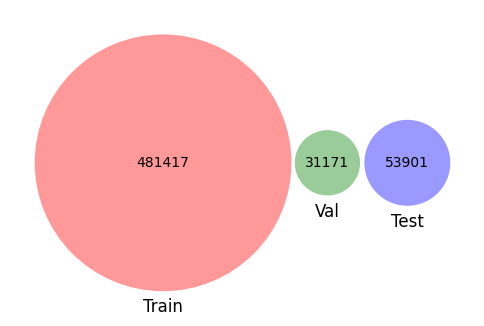

In [9]:
set1 = set(hvu_train_files['filename'])
set2 = set(hvu_val_files['filename'])
set3 = set(hvu_test_files['filename'])


plt.figure(figsize=(6,6))
venn3([set1, set2, set3], ['Train', 'Val', 'Test'])
plt.show()

In [10]:
def extract_timestamps_from_stripped_filename(filename):
    original_filename = filename
    # Use regex to split by underscore while ignoring empty segments caused by consecutive underscores
    parts = [part for part in re.split(r'(.*?)(\d+\.?\d*)_(\d+\.?\d*)\.mp4', filename) if part]
    # print(parts)
    
    # Assuming the last two parts of the filename are the timestamps
    if len(parts) >= 2:  # Ensure there are at least two parts
        start_time = float(parts[-2])
        end_time = float(parts[-1])
        filename = parts[0][:-1]
        return original_filename, filename, start_time, end_time
    
    return filename, None, None

In [11]:
# get youtube_id, time_start and time_end from the filename
hvu_val_files[['original_filename','filename', 'time_start', 'time_end']] = hvu_val_files['filename'].apply(lambda x: pd.Series(extract_timestamps_from_stripped_filename(x)))
hvu_train_files[['original_filename','filename', 'time_start', 'time_end']] = hvu_train_files['filename'].apply(lambda x: pd.Series(extract_timestamps_from_stripped_filename(x)))

In [12]:
hvu_val_files = hvu_val_files.rename(columns = {'filename': 'youtube_id'})
hvu_train_files = hvu_train_files.rename(columns = {'filename': 'youtube_id'})

In [13]:
# Combine the val_df with the val_files (filenames)
hvu_val_combined = hvu_val_df.merge(hvu_val_files, left_on=['youtube_id', 'time_start', 'time_end'], right_on=['youtube_id', 'time_start', 'time_end'], suffixes=('_df', '_file'), how='left')
hvu_train_combined = hvu_train_df.merge(hvu_train_files, left_on=['youtube_id', 'time_start', 'time_end'], right_on=['youtube_id', 'time_start', 'time_end'], suffixes=('_df', '_file'), how='left')

In [14]:
hvu_val_combined

,Tags,youtube_id,time_start,time_end,original_filename
0,striking_combat_sports|uniform|competition|jap...,gD_G1b0wV5I,101.5,103.5,gD_G1b0wV5I_101.5_103.5.mp4
1,house|plant|sky|residential_area|land_lot|tree...,eeEC-oWWAM0,90.5,92.5,eeEC-oWWAM0_90.5_92.5.mp4
2,water|swimmer|floating|leisure|playing_water_p...,Np0jqmKPvSQ,170.5,172.5,Np0jqmKPvSQ_170.5_172.5.mp4
3,percussion|cymbal|drumhead|metal|skin_head_per...,s2I4-ErSc7E,182.0,184.0,s2I4-ErSc7E_182.0_184.0.mp4
4,fixing_the_roof|wood,TLZXKaS2abQ,31.0,33.0,TLZXKaS2abQ_31.0_33.0.mp4
...,...,...,...,...,...
31166,nature_reserve|landscape|sky|golf_club|grassla...,2DFbuKXNmKQ,8.0,18.0,2DFbuKXNmKQ_000008_000018.mp4
31167,beauty|smile|close_up|forehead|black_hair|mage...,kDjlVB769V8,144.0,154.0,kDjlVB769V8_000144_000154.mp4
31168,rock_climbing|mountaineer|geology|geological_p...,L0vUeYaSPo0,13.0,23.0,L0vUeYaSPo0_000013_000023.mp4
31169,finger|furniture|flautist|fun|playing_recorder...,xDj_Y9D1le4,770.0,780.0,xDj_Y9D1le4_000770_000780.mp4


In [15]:
hvu_train_combined

,Tags,youtube_id,time_start,time_end,original_filename
0,brass_instrument|musical_instrument|trumpet|wo...,OLpWTpTC4P8,57.0,67.0,OLpWTpTC4P8_000057_000067.mp4
1,gadget|electronic_musical_instrument|electroni...,pjj6zedpCQY,75.0,85.0,pjj6zedpCQY_000075_000085.mp4
2,photograph|joint|shoulder|nature|human_leg|fun...,_STSOsITd0E,3.0,13.0,_STSOsITd0E_000003_000013.mp4
3,mouth|child|fun|nose|hair|human_hair_color|hea...,0r_BGL3416g,406.0,416.0,0r_BGL3416g_000406_000416.mp4
4,photograph|violist|cellist|violin_family|night...,xsPKW4tZZBc,233.0,243.0,xsPKW4tZZBc_000233_000243.mp4
...,...,...,...,...,...
481412,summer|sport|fun|sport_venue|games|competition...,0Ymc8xw8l_g,9.5,11.5,0Ymc8xw8l_g_9.5_11.5.mp4
481413,riding_bumper_cars|mode_of_transport|car|darkn...,iFWlWbpTm1g,34.5,36.5,iFWlWbpTm1g_34.5_36.5.mp4
481414,downtown|neighbourhood|pedestrian|road|window|...,7CfgZITnsxs,17.0,19.0,7CfgZITnsxs_17.0_19.0.mp4
481415,riding_bumper_cars|mode_of_transport|vehicle|a...,3B4AlI56wGA,11.5,13.5,3B4AlI56wGA_11.5_13.5.mp4


In [16]:
print(f"Total items in HVU train dataset after combining: {hvu_train_combined.shape[0]}")
print(f"Total items in HVU val dataset after combining: {hvu_val_combined.shape[0]}")

Total items in HVU train dataset after combining: 481417
Total items in HVU val dataset after combining: 31171


### CVDF K400

In [17]:
cvd_train_df = pd.read_csv("/home/ahmad/cvr/zero_shot/cvdf_datasets/k400/train.csv")
cvd_val_df = pd.read_csv("/home/ahmad/cvr/zero_shot/cvdf_datasets/k400/val.csv")
cvd_test_df = pd.read_csv("/home/ahmad/cvr/zero_shot/cvdf_datasets/k400/test.csv")

In [18]:
cvd_train_df['filename'] = cvd_train_df['youtube_id'] + '_' + cvd_train_df['time_start'].astype(str).str.zfill(6) + '_' + cvd_train_df['time_end'].astype(str).str.zfill(6) + '.mp4'
cvd_val_df['filename'] = cvd_val_df['youtube_id'] + '_' + cvd_val_df['time_start'].astype(str).str.zfill(6) + '_' + cvd_val_df['time_end'].astype(str).str.zfill(6) + '.mp4'
cvd_test_df['filename'] = cvd_test_df['youtube_id'] + '_' + cvd_test_df['time_start'].astype(str).str.zfill(6) + '_' + cvd_test_df['time_end'].astype(str).str.zfill(6) + '.mp4'

In [19]:
cvd_train_df

,label,youtube_id,time_start,time_end,split,is_cc,filename
0,abseiling,-3B32lodo2M,59,69,train,0,-3B32lodo2M_000059_000069.mp4
1,abseiling,-7kbO0v4hag,107,117,train,0,-7kbO0v4hag_000107_000117.mp4
2,abseiling,-bwYZwnwb8E,13,23,train,0,-bwYZwnwb8E_000013_000023.mp4
3,abseiling,-Cv3NwxG_8g,87,97,train,0,-Cv3NwxG_8g_000087_000097.mp4
4,abseiling,-hLv_HL6UhY,151,161,train,0,-hLv_HL6UhY_000151_000161.mp4
...,...,...,...,...,...,...,...
246529,zumba,_GRX1r0JV30,39,49,train,0,_GRX1r0JV30_000039_000049.mp4
246530,zumba,_JuIL8GGX0A,150,160,train,0,_JuIL8GGX0A_000150_000160.mp4
246531,zumba,_Jun6C7ICps,37,47,train,0,_Jun6C7ICps_000037_000047.mp4
246532,zumba,_SyAhrLns4k,200,210,train,0,_SyAhrLns4k_000200_000210.mp4


In [20]:
# Add split_name to identify which part the data belongs to 
cvd_train_df['split'] = 'train'
cvd_val_df['split'] = 'val'
cvd_test_df['split'] = 'test'

In [21]:
print(f"Total items in train file: {cvd_train_df.shape[0]}")
print(f"Total items in val file: {cvd_val_df.shape[0]}")
print(f"Total items in test file: {cvd_test_df.shape[0]}")

Total items in train file: 246534
Total items in val file: 19906
Total items in test file: 39805


In [22]:
# Unique labels in dataset
print(f"Unique labels in Train set: {cvd_train_df['label'].nunique()}")
print(f"Unique labels in Val set: {cvd_val_df['label'].nunique()}")
print(f"Unique labels in Test set: {cvd_test_df['label'].nunique()}")

Unique labels in Train set: 400
Unique labels in Val set: 400
Unique labels in Test set: 400


#### Label List

In [23]:
cvd_label_list = pd.read_csv("/home/ahmad/cvr/zero_shot/K400/cvdf/kinetics_400_labels.csv")
cvd_label_list

,id,name
0,0,abseiling
1,1,air drumming
2,2,answering questions
3,3,applauding
4,4,applying cream
...,...,...
395,395,wrestling
396,396,writing
397,397,yawning
398,398,yoga


In [24]:
def clean_label(label):
    try:
        if label:
            # Replace parentheses , convert to lowercase, and normalize spaces
            cleaned = label.replace('(', '').replace(')', '').strip().lower()
            # Replace multiple spaces with a single space
            cleaned = re.sub(r'\s+', ' ', cleaned)
            cleaned = cleaned.replace(' ', '_')
            return cleaned
        else:
            return None
    except Exception as e:
        print(label, e)

Labels after cleaning

In [25]:
cvd_label_list['name'] = cvd_label_list['name'].apply(clean_label)
cvd_label_list

,id,name
0,0,abseiling
1,1,air_drumming
2,2,answering_questions
3,3,applauding
4,4,applying_cream
...,...,...
395,395,wrestling
396,396,writing
397,397,yawning
398,398,yoga


#### Common/duplicate items in train/val

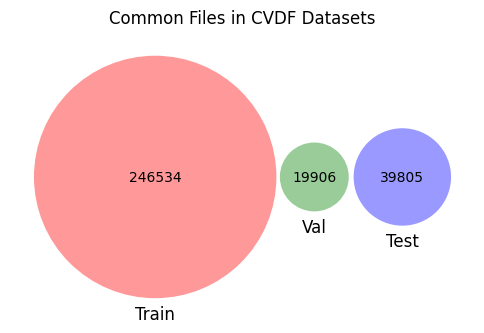

In [26]:
# Extract filenames as sets
set1 = set(cvd_train_df['filename'])
set2 = set(cvd_val_df['filename'])
set3 = set(cvd_test_df['filename'])


# Create a Venn diagram
plt.figure(figsize=(6, 6))
venn = venn3([set1, set2, set3], ('Train', 'Val', 'Test'))
plt.title("Common Files in CVDF Datasets")
plt.show()

#### Combined Dataset

In [27]:
cvd_combined_df = pd.concat([cvd_train_df, cvd_val_df, cvd_test_df])
print(f"Total items in Combined dataset : {cvd_combined_df.shape[0]}")

# Remove duplicates in combined dataset
cvd_combined_df = cvd_combined_df.drop_duplicates(subset='filename')
print(f"Total items after dropping duplicate items from the dataset: {cvd_combined_df.shape[0]}")

Total items in Combined dataset : 306245
Total items after dropping duplicate items from the dataset: 306245


In [28]:
# converting to float because HVU timestamps are in float
cvd_combined_df['time_start'] = cvd_combined_df['time_start'].astype(np.float32)
cvd_combined_df['time_end'] = cvd_combined_df['time_end'].astype(np.float32)

Common items between HVU and CVD based on youtube_id, time_start and time_end

In [29]:
# Common items in HVU Val and CVD Combined
common_df = pd.merge(hvu_val_combined, cvd_combined_df, on=['youtube_id', 'time_start', 'time_end'], how='inner', suffixes=('_hvu_val', '_k400'))
print(f"Total common items between HVU Val and CVD Combined dataset: {common_df.shape[0]}")
common_df.head()

Total common items between HVU Val and CVD Combined dataset: 13800


,Tags,youtube_id,time_start,time_end,original_filename,label,split,is_cc,filename
0,finger|black_hair|fun|laughing|windshield|vehi...,Y3srcQZOhks,25.0,35.0,Y3srcQZOhks_000025_000035.mp4,laughing,val,0,Y3srcQZOhks_000025_000035.mp4
1,service|faucet|tableware|washing_dishes|glass|...,8IqHQwVqg8g,76.0,86.0,8IqHQwVqg8g_000076_000086.mp4,washing dishes,train,0,8IqHQwVqg8g_000076_000086.mp4
2,electronics|art|performance|guitarist|electron...,ap1IV_BKAXo,4.0,14.0,ap1IV_BKAXo_000004_000014.mp4,playing bass guitar,val,0,ap1IV_BKAXo_000004_000014.mp4
3,furniture|sitting|clothing|trousers|room|servi...,IhiKd5JSrgo,337.0,347.0,IhiKd5JSrgo_000337_000347.mp4,washing feet,val,0,IhiKd5JSrgo_000337_000347.mp4
4,plant|leisure|fun|male|nature|tree|grass|recre...,DMDe-I5VzQA,98.0,108.0,DMDe-I5VzQA_000098_000108.mp4,spinning poi,val,0,DMDe-I5VzQA_000098_000108.mp4


In [30]:
# Unique items in HVU Val not in CVD Combined
in_hvu_val_df = pd.merge(hvu_val_combined, cvd_combined_df, on=['youtube_id', 'time_start', 'time_end'], how='left', suffixes=('_hvu_val', '_k400'), indicator=True)
in_hvu_val_df  = in_hvu_val_df[in_hvu_val_df['_merge'] == 'left_only']
in_hvu_val_df = in_hvu_val_df.drop(columns=['label', 'split', 'is_cc', 'filename', '_merge'])
in_hvu_val_df = in_hvu_val_df.reset_index(drop=True)
print(f"Total items in HVU Val and not in CVD Combined dataset: {in_hvu_val_df.shape[0]}")

Total items in HVU Val and not in CVD Combined dataset: 17371


In [31]:
# All the files in HVU Val that are not in K400 Combined(Train, Test, Val) based on youtube_id, time_start and time_end
in_hvu_val_df

,Tags,youtube_id,time_start,time_end,original_filename
0,striking_combat_sports|uniform|competition|jap...,gD_G1b0wV5I,101.5,103.5,gD_G1b0wV5I_101.5_103.5.mp4
1,house|plant|sky|residential_area|land_lot|tree...,eeEC-oWWAM0,90.5,92.5,eeEC-oWWAM0_90.5_92.5.mp4
2,water|swimmer|floating|leisure|playing_water_p...,Np0jqmKPvSQ,170.5,172.5,Np0jqmKPvSQ_170.5_172.5.mp4
3,percussion|cymbal|drumhead|metal|skin_head_per...,s2I4-ErSc7E,182.0,184.0,s2I4-ErSc7E_182.0_184.0.mp4
4,fixing_the_roof|wood,TLZXKaS2abQ,31.0,33.0,TLZXKaS2abQ_31.0_33.0.mp4
...,...,...,...,...,...
17366,art|muscle|dance|performance|night|choreograph...,kd7Pc3QjJDw,1012.0,1022.0,kd7Pc3QjJDw_001012_001022.mp4
17367,massage|skin|muscle|hair|forehead|black_hair|s...,9oGWxXgbsfE,135.0,145.0,9oGWxXgbsfE_000135_000145.mp4
17368,finger|packaging_and_labeling|cardboard_box|pa...,gGfJtwK6GZk,21.0,31.0,gGfJtwK6GZk_000021_000031.mp4
17369,dancer|choreography|dance|fun|girl|footwear|pe...,x5lYDVar2Tg,52.0,62.0,x5lYDVar2Tg_000052_000062.mp4


In [32]:
# Unique items in HVU Train not in CVD Combined
in_hvu_train_df = pd.merge(hvu_train_combined, cvd_combined_df, on=['youtube_id', 'time_start', 'time_end'], how='left', suffixes=('_hvu_train', '_k400'), indicator=True)
in_hvu_train_df  = in_hvu_train_df[in_hvu_train_df['_merge'] == 'left_only']
in_hvu_train_df = in_hvu_train_df.drop(columns=['label', 'split', 'is_cc', 'filename', '_merge'])
in_hvu_train_df = in_hvu_train_df.reset_index(drop=True)
print(f"Total items in HVU Train and not in CVD Combined dataset: {in_hvu_train_df.shape[0]}")

Total items in HVU Train and not in CVD Combined dataset: 310829


In [33]:
in_hvu_train_df

,Tags,youtube_id,time_start,time_end,original_filename
0,musical_instrument|woodwind_instrument|flute|a...,EFTdEz8vIlA,75.0,85.0,EFTdEz8vIlA_000075_000085.mp4
1,child|loudspeaker|fun|speaker|electronic_devic...,3Qm_A6zhKSo,0.0,10.0,3Qm_A6zhKSo_000000_000010.mp4
2,skateboarding_equipment_and_supplies|photograp...,R1bhMNaMxcU,0.0,10.0,R1bhMNaMxcU_000000_000010.mp4
3,brass_instrument|musical_instrument|saxophone|...,a47xt5A2GrI,41.0,51.0,a47xt5A2GrI_000041_000051.mp4
4,musical_instrument|electronic_musical_instrume...,EdbktrBv9So,35.0,45.0,EdbktrBv9So_000035_000045.mp4
...,...,...,...,...,...
310824,summer|sport|fun|sport_venue|games|competition...,0Ymc8xw8l_g,9.5,11.5,0Ymc8xw8l_g_9.5_11.5.mp4
310825,riding_bumper_cars|mode_of_transport|car|darkn...,iFWlWbpTm1g,34.5,36.5,iFWlWbpTm1g_34.5_36.5.mp4
310826,downtown|neighbourhood|pedestrian|road|window|...,7CfgZITnsxs,17.0,19.0,7CfgZITnsxs_17.0_19.0.mp4
310827,riding_bumper_cars|mode_of_transport|vehicle|a...,3B4AlI56wGA,11.5,13.5,3B4AlI56wGA_11.5_13.5.mp4


Removing on the basis of (exact matching) labels

For val dataset

In [34]:
label_set = set(cvd_label_list['name'])

#Identify items with matching and non-matching labels
def contains_label(tags):
    # Split the Tags column into individual labels
    tags_set = set(tags.split("|"))
    # Check if there's any overlap between the tags and the label set
    # if bool(tags_set & label_set):
    #     print(tags_set & label_set)
    return bool(tags_set & label_set)

In [35]:
# Add a column to Dataset 2 to flag matching labels
in_hvu_val_df["contains_label"] = in_hvu_val_df["Tags"].apply(contains_label)

In [36]:
in_hvu_val_df[in_hvu_val_df['contains_label'] == True]

,Tags,youtube_id,time_start,time_end,original_filename,contains_label
9,race_track|motorcycling|arena|doing_motocross|...,tIiw7Z33T3U,184.0,186.0,tIiw7Z33T3U_184.0_186.0.mp4,True
28,bowling_pin|leisure|bowling|fun|playing_ten_pi...,N8rm2LALPkM,10.5,12.5,N8rm2LALPkM_10.5_12.5.mp4,True
31,plant|musical_ensemble|festival|marching|stree...,RUGnGv9J5f8,118.5,120.5,RUGnGv9J5f8_118.5_120.5.mp4,True
56,musical_ensemble|percussion|marching|musician|...,LEXuyQuKmfU,20.5,22.5,LEXuyQuKmfU_20.5_22.5.mp4,True
62,finger|flautist|pipe|brass_instrument|clarinet...,yTYAmgOmQUI,40.5,42.5,yTYAmgOmQUI_40.5_42.5.mp4,True
...,...,...,...,...,...,...
17346,rock_climbing|plaster|footwear|belay_device|wa...,4bYsk8Wo8aQ,349.0,359.0,4bYsk8Wo8aQ_000349_000359.mp4,True
17348,finger|office_supplies|art|writing|design|pen|...,bDGMHzHpsmo,1.0,11.0,bDGMHzHpsmo_000001_000011.mp4,True
17354,finger|foot|bandage|waxing_legs|service|skin|k...,L-OP7cP94zs,173.0,183.0,L-OP7cP94zs_000173_000183.mp4,True
17364,art|close_up|knitting|thumb|crochet|knitting_n...,7TxPfi31xFo,7.0,17.0,7TxPfi31xFo_000007_000017.mp4,True


In [37]:
wolabel_hvu_val_df = in_hvu_val_df[in_hvu_val_df['contains_label'] == False]
label_hvu_val_df = in_hvu_val_df[in_hvu_val_df['contains_label'] == True]

# Reset index
wolabel_hvu_val_df = wolabel_hvu_val_df.reset_index(drop=True)
label_hvu_val_df = label_hvu_val_df.reset_index(drop=True)

In [38]:
print(f"Total items with matching labels in HVU val dataset: {label_hvu_val_df.shape[0]}")
print(f"Total items WITHOUT matching labels in HVU val dataset: {wolabel_hvu_val_df.shape[0]}")

Total items with matching labels in HVU val dataset: 5145
Total items WITHOUT matching labels in HVU val dataset: 12226


For training dataset

In [39]:
# Add a column to Dataset 2 to flag matching labels
in_hvu_train_df["contains_label"] = in_hvu_train_df["Tags"].apply(contains_label)

In [40]:
wolabel_hvu_train_df = in_hvu_train_df[in_hvu_train_df['contains_label'] == False]
label_hvu_train_df = in_hvu_train_df[in_hvu_train_df['contains_label'] == True]

# Reset index
wolabel_hvu_train_df = wolabel_hvu_train_df.reset_index(drop=True)
label_hvu_train_df = label_hvu_train_df.reset_index(drop=True)

In [41]:
print(f"Total items with matching labels in HVU train dataset: {label_hvu_train_df.shape[0]}")
print(f"Total items WITHOUT matching labels in HVU train dataset: {wolabel_hvu_train_df.shape[0]}")

Total items with matching labels in HVU train dataset: 101138
Total items WITHOUT matching labels in HVU train dataset: 209691


### Label Matching

In [42]:
# Map categories from HVU to it's labels
category_mapping = dict(zip(hvu_labels['Tag'], hvu_labels['Category']))

In [43]:
# Extract all unique labels from the 'Tags' column of Val Dataset
val_tags_list = wolabel_hvu_val_df['Tags'].str.split('|').explode().unique().tolist()
print(f"Total unique items in val tag list: {len(val_tags_list)}")
val_tags_list

Total unique items in val tag list: 2593


['striking_combat_sports',
 'uniform',
 'competition',
 'japanese_martial_arts',
 'doing_karate',
 'combat_sport',
 'contact_sport',
 'dobok',
 'crowd',
 'martial_arts',
 'sport_venue',
 'individual_sports',
 'house',
 'plant',
 'sky',
 'residential_area',
 'land_lot',
 'tree',
 'lawn',
 'suburb',
 'grass',
 'powerbocking',
 'recreation',
 'lane',
 'property',
 'road',
 'public_space',
 'asphalt',
 'real_estate',
 'water',
 'swimmer',
 'floating',
 'leisure',
 'playing_water_polo',
 'fun',
 'swimming',
 'indoor_games_and_sports',
 'water_ball_sports',
 'swimming_pool',
 'sport',
 'team_sport',
 'water_sport',
 'leisure_centre',
 'percussion',
 'cymbal',
 'drumhead',
 'metal',
 'skin_head_percussion_instrument',
 'drummer',
 'percussionist',
 'musical_instrument',
 'playing_congas',
 'percussion_instrument',
 'music',
 'bass_drum',
 'snare_drum',
 'drum',
 'percussion_accessory',
 'tom_tom_drum',
 'fixing_the_roof',
 'wood',
 'amusement_ride',
 'riding_bumper_cars',
 'vehicle',
 'automo

In [44]:
# Extract all unique labels from the 'Tags' column of Train Dataset
train_tags_list = wolabel_hvu_train_df['Tags'].str.split('|').explode().unique().tolist()
print(f"Total unique items in train tag list: {len(train_tags_list)}")
train_tags_list

Total unique items in train tag list: 2752


['child',
 'loudspeaker',
 'fun',
 'speaker',
 'electronic_device',
 'throwing_tantrum',
 'furniture',
 'standing',
 'electronics',
 'subwoofer',
 'audio_equipment',
 'home_appliance',
 'toddler',
 'table',
 'technology',
 'girl',
 'concrete',
 'photograph',
 'waving_hand',
 'blue',
 'performance',
 'musical_instrument',
 'performing_arts',
 'entertainment',
 'musician',
 'concert',
 'musical_instrument_accessory',
 'stage',
 'playing_pan_pipes',
 'musical_ensemble',
 'music',
 'percussion',
 'glasses',
 'night',
 'lighting',
 'hair',
 'human',
 'head',
 'darkness',
 'forehead',
 'man',
 'facial_hair',
 'eyewear',
 'playing_ocarina',
 'face',
 'mouth',
 'smile',
 'cheek',
 'nose',
 'eye',
 'chin',
 'skin',
 'neck',
 'arm',
 'smoking_pipe',
 'eyebrow',
 'lip',
 'jaw',
 'human_hair_color',
 'finger',
 'male',
 'backyard',
 'backflip_human_',
 'woody_plant',
 'grass',
 'leisure',
 'tree',
 'text',
 'line',
 'adventure',
 'vacation',
 'recreation',
 'sunlight',
 'lawn',
 'font',
 'plant',


In [45]:
# Combine train and val lists
# This list contains all the unique (exact matching) labels that are not present in the K400 dataset

combined_hvu_tag_list = train_tags_list + val_tags_list
combined_hvu_tag_list = list(set(combined_hvu_tag_list))
print(f"Total items in combined tag list: {len(combined_hvu_tag_list)}")

Total items in combined tag list: 2756


In [46]:
combined_hvu_tag_list

['ironing_hair',
 'supercar',
 'curling_sport_',
 'headphones',
 'adjusting_glasses',
 'kite',
 'fur',
 'drinker',
 'backboard',
 'guard_rail',
 'fast_food',
 'edger',
 'gin_and_tonic',
 'floristry',
 'chute',
 'wine',
 'historic_site',
 'drumhead',
 'orange',
 'caramel_color',
 'lighting_accessory',
 'cherry',
 'alligator_wrestling',
 'stallion',
 'pointer',
 'yakitori',
 'musical_ensemble',
 'school',
 'aerial_photography',
 'wetsuit',
 'beef_tenderloin',
 'meat_grinder',
 'base_jumping',
 'wicker_weaving',
 'mud',
 'goal',
 'wrist',
 'banner',
 'cosmetics',
 'fluvial_landforms_of_streams',
 'horse_tack',
 'cricket_bat',
 'dock',
 'dog',
 'field_lacrosse',
 'flint_knapping',
 'function_hall',
 'lever',
 'fault',
 'animal_source_foods',
 'giraffe',
 'conversation',
 'galliformes',
 'billboard',
 'redhead',
 'stunt_performer',
 'bus',
 'hearth',
 'bassinet',
 'martial_arts',
 'hospital_bed',
 'garden_roses',
 'rose_order',
 'sandbar',
 'household_cleaning_supply',
 'ancient_history',
 

In [47]:
def preprocess_word(word):
    """Remove special characters and replace them with a single space."""
    return re.sub(r'[^a-zA-Z0-9]', ' ', word).strip()

def find_similar_words(list1, list2, list1_name="List1 Word", list2_name="List2 Word"):
    """
    Preprocess two lists of words, remove special characters,
    and find similar words between the lists.
    """
    # Preprocess both lists
    processed_list1 = [preprocess_word(word) for word in list1]
    processed_list2 = [preprocess_word(word) for word in list2]

    # Find similar words (case-insensitive match)
    similar_words = []
    for word1, original_word1 in zip(processed_list1, list1):
        for word2, original_word2 in zip(processed_list2, list2):
            if word1.lower() == word2.lower():
                similar_words.append((original_word1, original_word2))

    # Create a DataFrame of similar words
    df = pd.DataFrame(similar_words, columns=[list1_name, list2_name])
    return df

In [48]:
#Identify items with matching and non-matching labels
def contains_label(tags, label_set):
    # Split the Tags column into individual labels
    tags_set = set(tags.split("|"))
    # Check if there's any overlap between the tags and the label set
    # if bool(tags_set & label_set):
    #     print(tags_set & label_set)
    return bool(tags_set & label_set)

In [49]:
df_similar = find_similar_words(list(label_set), combined_hvu_tag_list, 'K400', 'HVU')

In [50]:
df_similar

,K400,HVU
0,tying_knot_not_on_a_tie,tying_knot_not_on_a_tie_
1,passing_american_football_in_game,passing_american_football_in_game_
2,massaging_person's_head,massaging_person_s_head
3,hurling_sport,hurling_sport_
4,punching_person_boxing,punching_person_boxing_
5,shooting_goal_soccer,shooting_goal_soccer_
6,petting_animal_not_cat,petting_animal_not_cat_
7,using_remote_controller_not_gaming,using_remote_controller_not_gaming_


In [51]:
match_list1 = set(df_similar['HVU'].tolist())

In [52]:
# Add a column to Dataset 2 to flag matching labels
wolabel_hvu_val_df["contains_label"] = wolabel_hvu_val_df["Tags"].apply(lambda x: contains_label(x, match_list1))
wolabel_hvu_val_df = wolabel_hvu_val_df[wolabel_hvu_val_df['contains_label'] == False]
wolabel_hvu_val_df

,Tags,youtube_id,time_start,time_end,original_filename,contains_label
0,striking_combat_sports|uniform|competition|jap...,gD_G1b0wV5I,101.5,103.5,gD_G1b0wV5I_101.5_103.5.mp4,False
1,house|plant|sky|residential_area|land_lot|tree...,eeEC-oWWAM0,90.5,92.5,eeEC-oWWAM0_90.5_92.5.mp4,False
2,water|swimmer|floating|leisure|playing_water_p...,Np0jqmKPvSQ,170.5,172.5,Np0jqmKPvSQ_170.5_172.5.mp4,False
3,percussion|cymbal|drumhead|metal|skin_head_per...,s2I4-ErSc7E,182.0,184.0,s2I4-ErSc7E_182.0_184.0.mp4,False
4,fixing_the_roof|wood,TLZXKaS2abQ,31.0,33.0,TLZXKaS2abQ_31.0_33.0.mp4,False
...,...,...,...,...,...,...
12220,lighting|finger|moustache|facial_hair|conversa...,Ojk4Q7bS-VM,5.0,15.0,Ojk4Q7bS-VM_000005_000015.mp4,False
12221,massaging_neck|finger|neck|service|skin|girl|p...,vOFCraGyYPo,467.0,477.0,vOFCraGyYPo_000467_000477.mp4,False
12223,finger|packaging_and_labeling|cardboard_box|pa...,gGfJtwK6GZk,21.0,31.0,gGfJtwK6GZk_000021_000031.mp4,False
12224,dancer|choreography|dance|fun|girl|footwear|pe...,x5lYDVar2Tg,52.0,62.0,x5lYDVar2Tg_000052_000062.mp4,False


In [53]:
# Add a column to Dataset 2 to flag matching labels
wolabel_hvu_train_df["contains_label"] = wolabel_hvu_train_df["Tags"].apply(lambda x: contains_label(x, match_list1))
wolabel_hvu_train_df = wolabel_hvu_train_df[wolabel_hvu_train_df['contains_label'] == False]
wolabel_hvu_train_df

,Tags,youtube_id,time_start,time_end,original_filename,contains_label
0,child|loudspeaker|fun|speaker|electronic_devic...,3Qm_A6zhKSo,0.0,10.0,3Qm_A6zhKSo_000000_000010.mp4,False
1,concrete|photograph|child|fun|waving_hand|blue,7BbDqZc_tPU,0.0,10.0,7BbDqZc_tPU_000000_000010.mp4,False
2,performance|musical_instrument|performing_arts...,gfQUg9PHs14,300.0,310.0,gfQUg9PHs14_000300_000310.mp4,False
3,glasses|night|fun|musician|lighting|hair|human...,lx2-z9f-Jho,0.0,10.0,lx2-z9f-Jho_000000_000010.mp4,False
4,mouth|hair|smile|cheek|glasses|nose|head|eye|c...,D1666cuDZts,17.0,27.0,D1666cuDZts_000017_000027.mp4,False
...,...,...,...,...,...,...
209686,summer|sport|fun|sport_venue|games|competition...,0Ymc8xw8l_g,9.5,11.5,0Ymc8xw8l_g_9.5_11.5.mp4,False
209687,riding_bumper_cars|mode_of_transport|car|darkn...,iFWlWbpTm1g,34.5,36.5,iFWlWbpTm1g_34.5_36.5.mp4,False
209688,downtown|neighbourhood|pedestrian|road|window|...,7CfgZITnsxs,17.0,19.0,7CfgZITnsxs_17.0_19.0.mp4,False
209689,riding_bumper_cars|mode_of_transport|vehicle|a...,3B4AlI56wGA,11.5,13.5,3B4AlI56wGA_11.5_13.5.mp4,False


In [54]:
match_list2 = [
    'making_the_bed',
    'cooking_sausages_not_on_barbeque_',
    'opening_bottle_not_wine_',
    'person_collecting_garbage',
    'card_game',
    'changing_wheel_not_on_bike_',
    'hugging_not_baby_',
    'inflating_balloons',
    'skiing',
    'dyeing_hair',
    
    'passing_soccer_ball',
    'alpine_skiing',
    'skiing',
    'fishing',
    'tying_necktie',
    'combing_hair',
    'boxing',
    'basketball_moves',
    
    
]
match_list2 = set(match_list2)

In [55]:
# Add a column to Dataset 2 to flag matching labels
wolabel_hvu_train_df["contains_label"] = wolabel_hvu_train_df["Tags"].apply(lambda x: contains_label(x, match_list2))
wolabel_hvu_train_df = wolabel_hvu_train_df[wolabel_hvu_train_df['contains_label'] == False]
wolabel_hvu_train_df

,Tags,youtube_id,time_start,time_end,original_filename,contains_label
0,child|loudspeaker|fun|speaker|electronic_devic...,3Qm_A6zhKSo,0.0,10.0,3Qm_A6zhKSo_000000_000010.mp4,False
1,concrete|photograph|child|fun|waving_hand|blue,7BbDqZc_tPU,0.0,10.0,7BbDqZc_tPU_000000_000010.mp4,False
2,performance|musical_instrument|performing_arts...,gfQUg9PHs14,300.0,310.0,gfQUg9PHs14_000300_000310.mp4,False
3,glasses|night|fun|musician|lighting|hair|human...,lx2-z9f-Jho,0.0,10.0,lx2-z9f-Jho_000000_000010.mp4,False
4,mouth|hair|smile|cheek|glasses|nose|head|eye|c...,D1666cuDZts,17.0,27.0,D1666cuDZts_000017_000027.mp4,False
...,...,...,...,...,...,...
209686,summer|sport|fun|sport_venue|games|competition...,0Ymc8xw8l_g,9.5,11.5,0Ymc8xw8l_g_9.5_11.5.mp4,False
209687,riding_bumper_cars|mode_of_transport|car|darkn...,iFWlWbpTm1g,34.5,36.5,iFWlWbpTm1g_34.5_36.5.mp4,False
209688,downtown|neighbourhood|pedestrian|road|window|...,7CfgZITnsxs,17.0,19.0,7CfgZITnsxs_17.0_19.0.mp4,False
209689,riding_bumper_cars|mode_of_transport|vehicle|a...,3B4AlI56wGA,11.5,13.5,3B4AlI56wGA_11.5_13.5.mp4,False


In [56]:
# Add a column to Dataset 2 to flag matching labels
wolabel_hvu_val_df["contains_label"] = wolabel_hvu_val_df["Tags"].apply(lambda x: contains_label(x, match_list2))
wolabel_hvu_val_df = wolabel_hvu_val_df[wolabel_hvu_val_df['contains_label'] == False]
wolabel_hvu_val_df

,Tags,youtube_id,time_start,time_end,original_filename,contains_label
0,striking_combat_sports|uniform|competition|jap...,gD_G1b0wV5I,101.5,103.5,gD_G1b0wV5I_101.5_103.5.mp4,False
1,house|plant|sky|residential_area|land_lot|tree...,eeEC-oWWAM0,90.5,92.5,eeEC-oWWAM0_90.5_92.5.mp4,False
2,water|swimmer|floating|leisure|playing_water_p...,Np0jqmKPvSQ,170.5,172.5,Np0jqmKPvSQ_170.5_172.5.mp4,False
3,percussion|cymbal|drumhead|metal|skin_head_per...,s2I4-ErSc7E,182.0,184.0,s2I4-ErSc7E_182.0_184.0.mp4,False
4,fixing_the_roof|wood,TLZXKaS2abQ,31.0,33.0,TLZXKaS2abQ_31.0_33.0.mp4,False
...,...,...,...,...,...,...
12220,lighting|finger|moustache|facial_hair|conversa...,Ojk4Q7bS-VM,5.0,15.0,Ojk4Q7bS-VM_000005_000015.mp4,False
12221,massaging_neck|finger|neck|service|skin|girl|p...,vOFCraGyYPo,467.0,477.0,vOFCraGyYPo_000467_000477.mp4,False
12223,finger|packaging_and_labeling|cardboard_box|pa...,gGfJtwK6GZk,21.0,31.0,gGfJtwK6GZk_000021_000031.mp4,False
12224,dancer|choreography|dance|fun|girl|footwear|pe...,x5lYDVar2Tg,52.0,62.0,x5lYDVar2Tg_000052_000062.mp4,False


In [57]:
combined_hvu_tag_list = [item for item in combined_hvu_tag_list if item not in match_list1 and item not in match_list2]
print(f"Tags in HVU after removing 8 matching tags: {len(combined_hvu_tag_list)}")

Tags in HVU after removing 8 matching tags: 2731


In [58]:
filtered_labels = pd.DataFrame(combined_hvu_tag_list, columns=['Tag']).sort_values(ascending=True, by='Tag')
# filtered_labels.to_csv("./filtered_labels.csv", header=False)

In [59]:
filtered_labels = filtered_labels.reset_index(drop=True)
filtered_labels

,Tag
0,800_metres
1,abdomen
2,academic_dress
3,accordion
4,accordionist
...,...
2726,yarn_spinning
2727,yellow
2728,yolk
2729,youth


In [60]:

filtered_labels = filtered_labels.merge(hvu_labels, on='Tag', how='left').sort_values(by=['Category', 'Tag'])
filtered_labels = filtered_labels.reset_index(drop=True)
filtered_labels['Label'] = range(len(filtered_labels))
filtered_labels

,Tag,Category,Label
0,acrobatics,action,0
1,acting_in_play,action,1
2,adjusting_glasses,action,2
3,alligator_wrestling,action,3
4,american_football,action,4
...,...,...,...
2726,wetland,scene,2726
2727,wildlife_region,scene,2727
2728,workshop,scene,2728
2729,yard,scene,2729


In [61]:
filtered_labels

,Tag,Category,Label
0,acrobatics,action,0
1,acting_in_play,action,1
2,adjusting_glasses,action,2
3,alligator_wrestling,action,3
4,american_football,action,4
...,...,...,...
2726,wetland,scene,2726
2727,wildlife_region,scene,2727
2728,workshop,scene,2728
2729,yard,scene,2729


In [62]:
filtered_labels.to_csv("./filtered_labels_2.csv", index=False)

In [59]:
# .str.split('|').explode().unique().tolist()

In [63]:
# Create a mapping from Tag to Label
tag_to_label = dict(zip(filtered_labels['Tag'], filtered_labels['Label']))

In [64]:
# Function to get labels for each row
def map_labels(tags):
    # Split the 'Tags' string into individual tags
    tag_list = tags.split('|')
    # Map each tag to its label if it exists in the mapping
    labels = [str(tag_to_label[tag]) for tag in tag_list if tag in tag_to_label]
    # Join the labels with '|'
    return '|'.join(labels)

In [65]:
# Apply the function to the Tags column
wolabel_hvu_val_df['label'] = wolabel_hvu_val_df['Tags'].copy().apply(map_labels)

/tmp/ipykernel_9676/4119670841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wolabel_hvu_val_df['label'] = wolabel_hvu_val_df['Tags'].copy().apply(map_labels)


In [67]:
wolabel_hvu_val_df

,Tags,youtube_id,time_start,time_end,original_filename,contains_label,label
0,striking_combat_sports|uniform|competition|jap...,gD_G1b0wV5I,101.5,103.5,gD_G1b0wV5I_101.5_103.5.mp4,False,717|2375|774|598|84|509|518|1325|524|622|2689|589
1,house|plant|sky|residential_area|land_lot|tree...,eeEC-oWWAM0,90.5,92.5,eeEC-oWWAM0_90.5_92.5.mp4,False,2593|1960|2685|2660|2604|2354|1707|2697|1543|2...
2,water|swimmer|floating|leisure|playing_water_p...,Np0jqmKPvSQ,170.5,172.5,Np0jqmKPvSQ_170.5_172.5.mp4,False,2414|2273|399|417|216|404|298|774|590|746|241|...
3,percussion|cymbal|drumhead|metal|skin_head_per...,s2I4-ErSc7E,182.0,184.0,s2I4-ErSc7E_182.0_184.0.mp4,False,183|1295|1348|422|2161|1349|1924|1838|196|1923...
4,fixing_the_roof|wood,TLZXKaS2abQ,31.0,33.0,TLZXKaS2abQ_31.0_33.0.mp4,False,102|461
...,...,...,...,...,...,...,...
12220,lighting|finger|moustache|facial_hair|conversa...,Ojk4Q7bS-VM,5.0,15.0,Ojk4Q7bS-VM_000005_000015.mp4,False,607|1424|1828|1401|778|572|195|410|1760|360|15...
12221,massaging_neck|finger|neck|service|skin|girl|p...,vOFCraGyYPo,467.0,477.0,vOFCraGyYPo_000467_000477.mp4,False,164|1424|1845|689|2160|1518|1911|797|1634|1835...
12223,finger|packaging_and_labeling|cardboard_box|pa...,gGfJtwK6GZk,21.0,31.0,gGfJtwK6GZk_000021_000031.mp4,False,1424|655|1112|178|1042|437|377|882|1571
12224,dancer|choreography|dance|fun|girl|footwear|pe...,x5lYDVar2Tg,52.0,62.0,x5lYDVar2Tg_000052_000062.mp4,False,1299|52|76|404|1518|1470|660|288|1257|2597|221...


In [66]:
wolabel_hvu_val_df.to_csv('hvu_cvdf_val_all_labels2.csv', index=False)

In [68]:
# Apply the function to the Tags column
wolabel_hvu_train_df['label'] = wolabel_hvu_train_df['Tags'].copy().apply(map_labels)

/tmp/ipykernel_9676/2670099235.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wolabel_hvu_train_df['label'] = wolabel_hvu_train_df['Tags'].copy().apply(map_labels)


In [70]:
wolabel_hvu_train_df.to_csv('hvu_cvdf_train_all_labels2.csv', index=False)

In [69]:
wolabel_hvu_train_df

,Tags,youtube_id,time_start,time_end,original_filename,contains_label,label
0,child|loudspeaker|fun|speaker|electronic_devic...,3Qm_A6zhKSo,0.0,10.0,3Qm_A6zhKSo_000000_000010.mp4,False,1163|1746|404|2196|1373|311|1493|289|543|2256|...
1,concrete|photograph|child|fun|waving_hand|blue,7BbDqZc_tPU,0.0,10.0,7BbDqZc_tPU_000000_000010.mp4,False,386|186|1163|404|343|366
2,performance|musical_instrument|performing_arts...,gfQUg9PHs14,300.0,310.0,gfQUg9PHs14_000300_000310.mp4,False,660|1838|661|551|1841|775|1839|2692|209|726|64...
3,glasses|night|fun|musician|lighting|hair|human...,lx2-z9f-Jho,0.0,10.0,lx2-z9f-Jho_000000_000010.mp4,False,1521|802|404|1841|607|1562|1633|1591|389|1471|...
4,mouth|hair|smile|cheek|glasses|nose|head|eye|c...,D1666cuDZts,17.0,27.0,D1666cuDZts_000017_000027.mp4,False,1829|1562|278|1147|1521|1860|1591|1394|1164|21...
...,...,...,...,...,...,...,...
209686,summer|sport|fun|sport_venue|games|competition...,0Ymc8xw8l_g,9.5,11.5,0Ymc8xw8l_g_9.5_11.5.mp4,False,819|705|404|2689|572|774|417|2073|823|241|547|...
209687,riding_bumper_cars|mode_of_transport|car|darkn...,iFWlWbpTm1g,34.5,36.5,iFWlWbpTm1g_34.5_36.5.mp4,False,245|638|1104|389|1139|241|486|1075|1518
209688,downtown|neighbourhood|pedestrian|road|window|...,7CfgZITnsxs,17.0,19.0,7CfgZITnsxs_17.0_19.0.mp4,False,2551|2629|1917|2669|2453|2654|2711|223|241|264...
209689,riding_bumper_cars|mode_of_transport|vehicle|a...,3B4AlI56wGA,11.5,13.5,3B4AlI56wGA_11.5_13.5.mp4,False,245|638|2383|2486|417|241|1075


In [110]:
# Create a mapping of Tag -> Category
tag_to_category = dict(zip(filtered_labels['Tag'], filtered_labels['Category']))
tag_to_category

{'acrobatics': 'action',
 'acting_in_play': 'action',
 'adjusting_glasses': 'action',
 'alligator_wrestling': 'action',
 'alpine_skiing': 'action',
 'american_football': 'action',
 'angling': 'action',
 'archaeological_excavation': 'action',
 'arguing': 'action',
 'assembling_bicycle': 'action',
 'attending_conference': 'action',
 'auto_racing': 'action',
 'backflip_human_': 'action',
 'ball_game': 'action',
 'base_jumping': 'action',
 'baseball': 'action',
 'basketball_moves': 'action',
 'bathing': 'action',
 'bathing_dog': 'action',
 'baton_twirling': 'action',
 'battle_rope_training': 'action',
 'beach_soccer': 'action',
 'blowdrying_hair': 'action',
 'blowing_bubble_gum': 'action',
 'bmx': 'action',
 'boating': 'action',
 'bodybuilding': 'action',
 'bodysurfing': 'action',
 'bottling': 'action',
 'bouldering': 'action',
 'bouncing_on_bouncy_castle': 'action',
 'boxing': 'action',
 'breaking_boards': 'action',
 'breathing_fire': 'action',
 'building_lego': 'action',
 'building_sandc

In [111]:
# Group Tags by Category
categories = filtered_labels.groupby('Category')['Tag'].apply(list).to_dict()

In [119]:
filtered_labels['Category_Label'] = (
    filtered_labels.groupby('Category')
    .cumcount()
)  # Generate new labels starting from 0 within each category


In [121]:
filtered_labels[filtered_labels['Category'] == 'scene']

,Tag,Category,Label,Category_Label
16,aeolian_landform,scene,2490,0
37,aisle,scene,2491,1
45,alley,scene,2492,2
56,amusement_park,scene,2493,3
67,animal_shelter,scene,2494,4
...,...,...,...,...
2662,wetland,scene,2733,243
2687,wildlife_region,scene,2734,244
2720,workshop,scene,2735,245
2732,yard,scene,2736,246


In [122]:
# Step 2: Create a mapping of old labels to new labels
old_to_new_label_mapping = filtered_labels.set_index('Label')['Category_Label'].to_dict()
old_to_new_label_mapping

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 17,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 25,
 26: 26,
 27: 27,
 28: 28,
 29: 29,
 30: 30,
 31: 31,
 32: 32,
 33: 33,
 34: 34,
 35: 35,
 36: 36,
 37: 37,
 38: 38,
 39: 39,
 40: 40,
 41: 41,
 42: 42,
 43: 43,
 44: 44,
 45: 45,
 46: 46,
 47: 47,
 48: 48,
 49: 49,
 50: 50,
 51: 51,
 52: 52,
 53: 53,
 54: 54,
 55: 55,
 56: 56,
 57: 57,
 58: 58,
 59: 59,
 60: 60,
 61: 61,
 62: 62,
 63: 63,
 64: 64,
 65: 65,
 66: 66,
 67: 67,
 68: 68,
 69: 69,
 70: 70,
 71: 71,
 72: 72,
 73: 73,
 74: 74,
 75: 75,
 76: 76,
 77: 77,
 78: 78,
 79: 79,
 80: 80,
 81: 81,
 82: 82,
 83: 83,
 84: 84,
 85: 85,
 86: 86,
 87: 87,
 88: 88,
 89: 89,
 90: 90,
 91: 91,
 92: 92,
 93: 93,
 94: 94,
 95: 95,
 96: 96,
 97: 97,
 98: 98,
 99: 99,
 100: 100,
 101: 101,
 102: 102,
 103: 103,
 104: 104,
 105: 105,
 106: 106,
 107: 107,
 108: 108,
 109: 109,
 110: 110,

In [123]:
# Step 3: Update Dataset 1
# Function to map old labels in Dataset 1 to new labels
def update_labels(tags):
    tag_list = tags.split('|')
    # Map each tag to its new label (if it exists in the mapping)
    labels = [str(old_to_new_label_mapping[label]) for tag in tag_list if tag in old_to_new_label_mapping]
    # Join labels into a '|' separated string
    return '|'.join(labels)

In [125]:
# Update the 'label' column in Dataset 1
wolabel_hvu_val_df['label'] = wolabel_hvu_val_df['Tags'].apply(update_labels)

/tmp/ipykernel_9601/972943647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wolabel_hvu_val_df['label'] = wolabel_hvu_val_df['Tags'].apply(update_labels)


In [126]:
wolabel_hvu_val_df

,Tags,youtube_id,time_start,time_end,original_filename,contains_label,label
0,striking_combat_sports|uniform|competition|jap...,gD_G1b0wV5I,101.5,103.5,gD_G1b0wV5I_101.5_103.5.mp4,False,
1,house|plant|sky|residential_area|land_lot|tree...,eeEC-oWWAM0,90.5,92.5,eeEC-oWWAM0_90.5_92.5.mp4,False,
2,water|swimmer|floating|leisure|playing_water_p...,Np0jqmKPvSQ,170.5,172.5,Np0jqmKPvSQ_170.5_172.5.mp4,False,
3,percussion|cymbal|drumhead|metal|skin_head_per...,s2I4-ErSc7E,182.0,184.0,s2I4-ErSc7E_182.0_184.0.mp4,False,
4,fixing_the_roof|wood,TLZXKaS2abQ,31.0,33.0,TLZXKaS2abQ_31.0_33.0.mp4,False,
...,...,...,...,...,...,...,...
12220,lighting|finger|moustache|facial_hair|conversa...,Ojk4Q7bS-VM,5.0,15.0,Ojk4Q7bS-VM_000005_000015.mp4,False,
12221,massaging_neck|finger|neck|service|skin|girl|p...,vOFCraGyYPo,467.0,477.0,vOFCraGyYPo_000467_000477.mp4,False,
12223,finger|packaging_and_labeling|cardboard_box|pa...,gGfJtwK6GZk,21.0,31.0,gGfJtwK6GZk_000021_000031.mp4,False,
12224,dancer|choreography|dance|fun|girl|footwear|pe...,x5lYDVar2Tg,52.0,62.0,x5lYDVar2Tg_000052_000062.mp4,False,


In [60]:
str(combined_hvu_tag_list)

"['throwing_water_balloon', 'ligament', 'alcoholic_beverage', 'sunglasses', 'banquet', 'display_advertising', 'racket', 'water_polo_cap', 'auto_part', 'downhill_mountain_biking', 'roller_sport', 'emerald', 'polishing_forniture', 'uniform', 'street_art', 'throwing_ball_not_baseball_or_american_football_', 'exercise_equipment', 'tradition', 'cup', 'camera', 'physical_exercise', 'spread_mulch', 'windshield_wiper', 'jumping_bicycle', 'chain', 'play_vehicle', 'fashion_design', 'dairy_product', 'oyster_shell', 'fir', 'attending_conference', 'bead', 'cutting_orange', 'shopping_basket', 'ballet_dancer', 'logging', 'bicycle_drivetrain_part', 'stadium', 'print', 'vizsla', 'ball_over_a_net_games', 'swimwear', 'snow_tubing', 'clothes_hamper', 'yacht', 'soft_drink', 'stick', 'peel', 'ceramic', 'official', 'fashion_accessory', 'staring', 'greek_salad', 'traditional_sport', 'boa_constrictor', 'throwing_knife', 'coffee_bean', 'research', 'factory', 'bouldering', 'changing_gear_in_car', 'canoe', 'input

Matching similar words

In [129]:
def find_top_n_similar_and_sort(list1, list2, n=3):
    # Load the pre-trained sentence transformer model
    model = SentenceTransformer('all-MiniLM-L6-v2')

    # Compute embeddings for both lists
    embeddings1 = model.encode(list1, convert_to_tensor=True)
    embeddings2 = model.encode(list2, convert_to_tensor=True)

    # List to store results
    results = []

    for i, item in enumerate(list1):
        # Compute cosine similarity between the current item in list1 and all items in list2
        similarities = util.cos_sim(embeddings1[i], embeddings2)[0]

        # Get the top-n most similar items from list2
        top_n_indices = similarities.topk(n).indices
        top_n_scores = similarities[top_n_indices]

        # Prepare row for the DataFrame
        row = [item]
        similarity_sum = 0
        for j, idx in enumerate(top_n_indices):
            row.extend([list2[idx], float(top_n_scores[j])])
            similarity_sum += float(top_n_scores[j])
        
        # Add the sum of similarity scores as the last column
        row.append(similarity_sum)

        # Append the row to results
        results.append(row)

    # Create column names dynamically
    columns = ['Item']
    for i in range(1, n + 1):
        columns.extend([f'Similar {i}', f'Score {i}'])
    columns.append('Total Similarity Score')

    # Create a DataFrame
    df = pd.DataFrame(results, columns=columns)

    # Sort the DataFrame based on the 'Total Similarity Score' column in descending order
    df = df.sort_values(by='Total Similarity Score', ascending=False).reset_index(drop=True)

    return df


In [130]:
# Get the sorted DataFrame with top-n matches
n = 5
df_result = find_top_n_similar_and_sort(list(label_set), combined_hvu_tag_list, n=n)


In [131]:
df_result

,Item,Similar 1,Score 1,Similar 2,Score 2,Similar 3,Score 3,Similar 4,Score 4,Similar 5,Score 5,Total Similarity Score
0,ice_skating,ice_skate,0.947829,ice_rink,0.809404,figure_skating,0.809058,ice_swimming,0.783458,ice_hockey_rink,0.772795,4.122545
1,roller_skating,roller_skates,0.907467,roller_sport,0.881901,ice_skate,0.823872,figure_skating,0.767703,roller_blades,0.721121,4.102064
2,riding_mountain_bike,mountain_bike,0.930267,mountain_biking,0.887882,downhill_mountain_biking,0.795296,trail_bike,0.748333,exercise_bike,0.710528,4.072305
3,sailing,sail,0.885683,sailboat,0.848265,sailing_ship,0.792174,boating,0.775263,land_sailing,0.760409,4.061793
4,water_skiing,water_ski,0.916459,water_sport,0.792660,alpine_skiing,0.776564,skiing,0.759771,ski,0.751455,3.996909
...,...,...,...,...,...,...,...,...,...,...,...,...
395,testifying,court,0.538825,demonstration,0.403238,watch,0.392169,meeting,0.382436,speech,0.380467,2.097135
396,wrapping_present,christmas_decoration,0.431972,display_advertising,0.417097,auto_show,0.393223,active_undergarment,0.391680,fly_tying,0.389650,2.023621
397,using_segway,segway,0.803527,seat_belt,0.318149,car_seat,0.301278,bass_drum,0.292513,tying_necktie,0.288845,2.004311
398,presenting_weather_forecast,meteorological_phenomenon,0.548013,presentation,0.388823,snow_covered_landscape,0.360731,daytime,0.348288,winter,0.329237,1.975092


In [132]:
df_result.to_csv("top_n_similar.csv", index=False)

In [133]:
# Map each item in the "Similar 1", "Similar 2", etc., columns to their respective Category
def map_category_to_similar(similar_item):
    # Check if the similar item matches any tag in the second dataset
    category = hvu_labels[hvu_labels['Tag'] == similar_item]['Category']
    if not category.empty:
        return category.iloc[0]  # Return the category if found
    else:
        return None  # Return None if no match found

# Apply the function to each "Similar" column in df1
for i in range(1, 6):
    df_result[f'Category {i}'] = df_result[f'Similar {i}'].apply(map_category_to_similar)

# Display the updated DataFrame


In [134]:
df_result

,Item,Similar 1,Score 1,Similar 2,Score 2,Similar 3,Score 3,Similar 4,Score 4,Similar 5,Score 5,Total Similarity Score,Category 1,Category 2,Category 3,Category 4,Category 5
0,ice_skating,ice_skate,0.947829,ice_rink,0.809404,figure_skating,0.809058,ice_swimming,0.783458,ice_hockey_rink,0.772795,4.122545,object,scene,action,action,scene
1,roller_skating,roller_skates,0.907467,roller_sport,0.881901,ice_skate,0.823872,figure_skating,0.767703,roller_blades,0.721121,4.102064,object,concept,object,action,object
2,riding_mountain_bike,mountain_bike,0.930267,mountain_biking,0.887882,downhill_mountain_biking,0.795296,trail_bike,0.748333,exercise_bike,0.710528,4.072305,object,action,action,object,object
3,sailing,sail,0.885683,sailboat,0.848265,sailing_ship,0.792174,boating,0.775263,land_sailing,0.760409,4.061793,object,object,object,action,action
4,water_skiing,water_ski,0.916459,water_sport,0.792660,alpine_skiing,0.776564,skiing,0.759771,ski,0.751455,3.996909,object,concept,action,action,object
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,testifying,court,0.538825,demonstration,0.403238,watch,0.392169,meeting,0.382436,speech,0.380467,2.097135,concept,event,object,event,event
396,wrapping_present,christmas_decoration,0.431972,display_advertising,0.417097,auto_show,0.393223,active_undergarment,0.391680,fly_tying,0.389650,2.023621,object,concept,event,object,action
397,using_segway,segway,0.803527,seat_belt,0.318149,car_seat,0.301278,bass_drum,0.292513,tying_necktie,0.288845,2.004311,object,object,object,object,action
398,presenting_weather_forecast,meteorological_phenomenon,0.548013,presentation,0.388823,snow_covered_landscape,0.360731,daytime,0.348288,winter,0.329237,1.975092,concept,event,scene,attribute,event


In [135]:
df_result.to_csv("top_n_similar_with_category.csv", index=False)